# Webinar 2: Data Preprocessing — Master End-to-End Demonstration
### Real Practical Datasets: IBM Telco Churn | 20 Newsgroups | MNIST Digits
### Modern Algorithms: XGBoost | LinearSVC (SVM) | SVM RBF + KNN

## Architecture
```
                      +-----------------------------+
                      |          WEBINAR 2          |
                      |      DATA PREPROCESSING     |
                      +--------------+--------------+
                                     |
         +---------------------------+---------------------------+
         |                           |                           |
         v                           v                           v
+-----------------+         +-----------------+         +-----------------+
|     TABULAR     |         |      TEXT       |         |      IMAGE      |
+-----------------+         +-----------------+         +-----------------+
| • Profiling     |         | • Cleaning      |         | • Loading       |
| • Encoding      |         | • TF-IDF        |         | • Resize        |
| • Scaling       |         | • Numerical Feat|         | • Normalize     |
| • Imbalance     |         | • Imbalance     |         | • PCA           |
| • Train (XGBoost|         +--------+--------+         | • Reduced Feat  |
+--------+--------+                  |                  +--------+--------+
         |                           +-----------+               |
         |                                       |               |
         +---------------------------+-----------+---------------+
                                     |
                                     v
                        +-------------------------+
                        |       Evaluation        |
                        +------------+------------+
                                     |
                                     v
                        +-------------------------+
                        |  Compare Before vs After|
                        +-------------------------+
```

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt

from src.tabular import run_tabular_pipeline
from src.text import run_text_pipeline
from src.image import run_image_pipeline
from src.evaluation import build_master_comparison_report, print_master_comparison, generate_all_report_visuals

print('All Webinar 2 modules loaded successfully!')

All Webinar 2 modules loaded successfully!


## 1. Running All 3 Preprocessing Pipelines on Real Datasets

In [2]:
print('--- 1. Running Tabular Pipeline (IBM Telco Churn + XGBoost) ---')
tabular_results = run_tabular_pipeline('../data/tabular/telco_churn_raw.csv')

print('\n--- 2. Running Text Pipeline (20 Newsgroups + LinearSVC) ---')
text_results = run_text_pipeline('../data/text/newsgroups_raw.csv')

print('\n--- 3. Running Image Pipeline (Handwritten Digits + SVM RBF) ---')
image_results = run_image_pipeline('../data/image/raw')

print('\nAll 3 pipelines completed successfully!')

--- 1. Running Tabular Pipeline (IBM Telco Churn + XGBoost) ---


  Tabular | Baseline: Logistic Regression (Baseline) -> Preprocessed: XGBoost Classifier

--- 2. Running Text Pipeline (20 Newsgroups + LinearSVC) ---


  Text | Baseline: SGD Classifier -> Preprocessed: LinearSVC (Calibrated)
  Top TF-IDF keywords: writes, article, would, can, one



--- 3. Running Image Pipeline (Handwritten Digits + SVM RBF) ---
Loaded 537 images across 3 classes: ['0', '1', '2']


  Image | Baseline: Logistic Regression (raw 2352 dims) -> Preprocessed: SVM RBF (21 PCA dims)

All 3 pipelines completed successfully!


## 2. Downstream Convergence: Master Before vs After Comparison

In [3]:
master_df = build_master_comparison_report(tabular_results, text_results, image_results)
print_master_comparison(master_df)
master_df


                         WEBINAR 2: BEFORE VS AFTER PREPROCESSING COMPARISON

>>> MODALITY: 1. Tabular
---------------------------------------------------------------------------
             Metric  Baseline (Before)  Preprocessed (After)   Delta Relative Improvement
           Accuracy             0.8041                0.7825 -0.0216                -2.7%
          Precision             0.6640                0.5857 -0.0783               -11.8%
             Recall             0.5289                0.6146 +0.0857               +16.2%
   F1-Score (Macro)             0.7301                0.7252 -0.0049                -0.7%
F1-Score (Minority)             0.5888                0.5998 +0.0110                +1.9%
            ROC-AUC             0.8378                0.8370 -0.0008                -0.1%
---------------------------------------------------------------------------

>>> MODALITY: 2. Text
---------------------------------------------------------------------------
             Me

,Modality,Metric,Baseline (Before),Preprocessed (After),Delta,Relative Improvement
0,1. Tabular,Accuracy,0.8041,0.7825,-0.0216,-2.7%
1,1. Tabular,Precision,0.6640,0.5857,-0.0783,-11.8%
2,1. Tabular,Recall,0.5289,0.6146,+0.0857,+16.2%
3,1. Tabular,F1-Score (Macro),0.7301,0.7252,-0.0049,-0.7%
4,1. Tabular,F1-Score (Minority),0.5888,0.5998,+0.0110,+1.9%
5,1. Tabular,ROC-AUC,0.8378,0.8370,-0.0008,-0.1%
6,2. Text,Accuracy,0.8899,0.9596,+0.0697,+7.8%
7,2. Text,Precision,0.9020,0.9597,+0.0576,+6.4%
8,2. Text,Recall,0.8984,0.9675,+0.0691,+7.7%
9,2. Text,F1-Score (Macro),0.8887,0.9591,+0.0704,+7.9%


## 3. Publication-Grade Visual Reports

Generating comprehensive visual report charts...


-> Saved benchmark chart to: ../reports\before_vs_after_benchmarks.png


-> Saved scaling comparison plot to: ../reports\tabular_scaling_and_outliers.png


-> Saved Image PCA plot to: ../reports\image_pca_and_reconstruction.png


-> Saved confusion matrices to: ../reports\confusion_matrices_comparison.png
All visual reports generated in '../reports/'!
1. Benchmark Comparison Across Modalities:


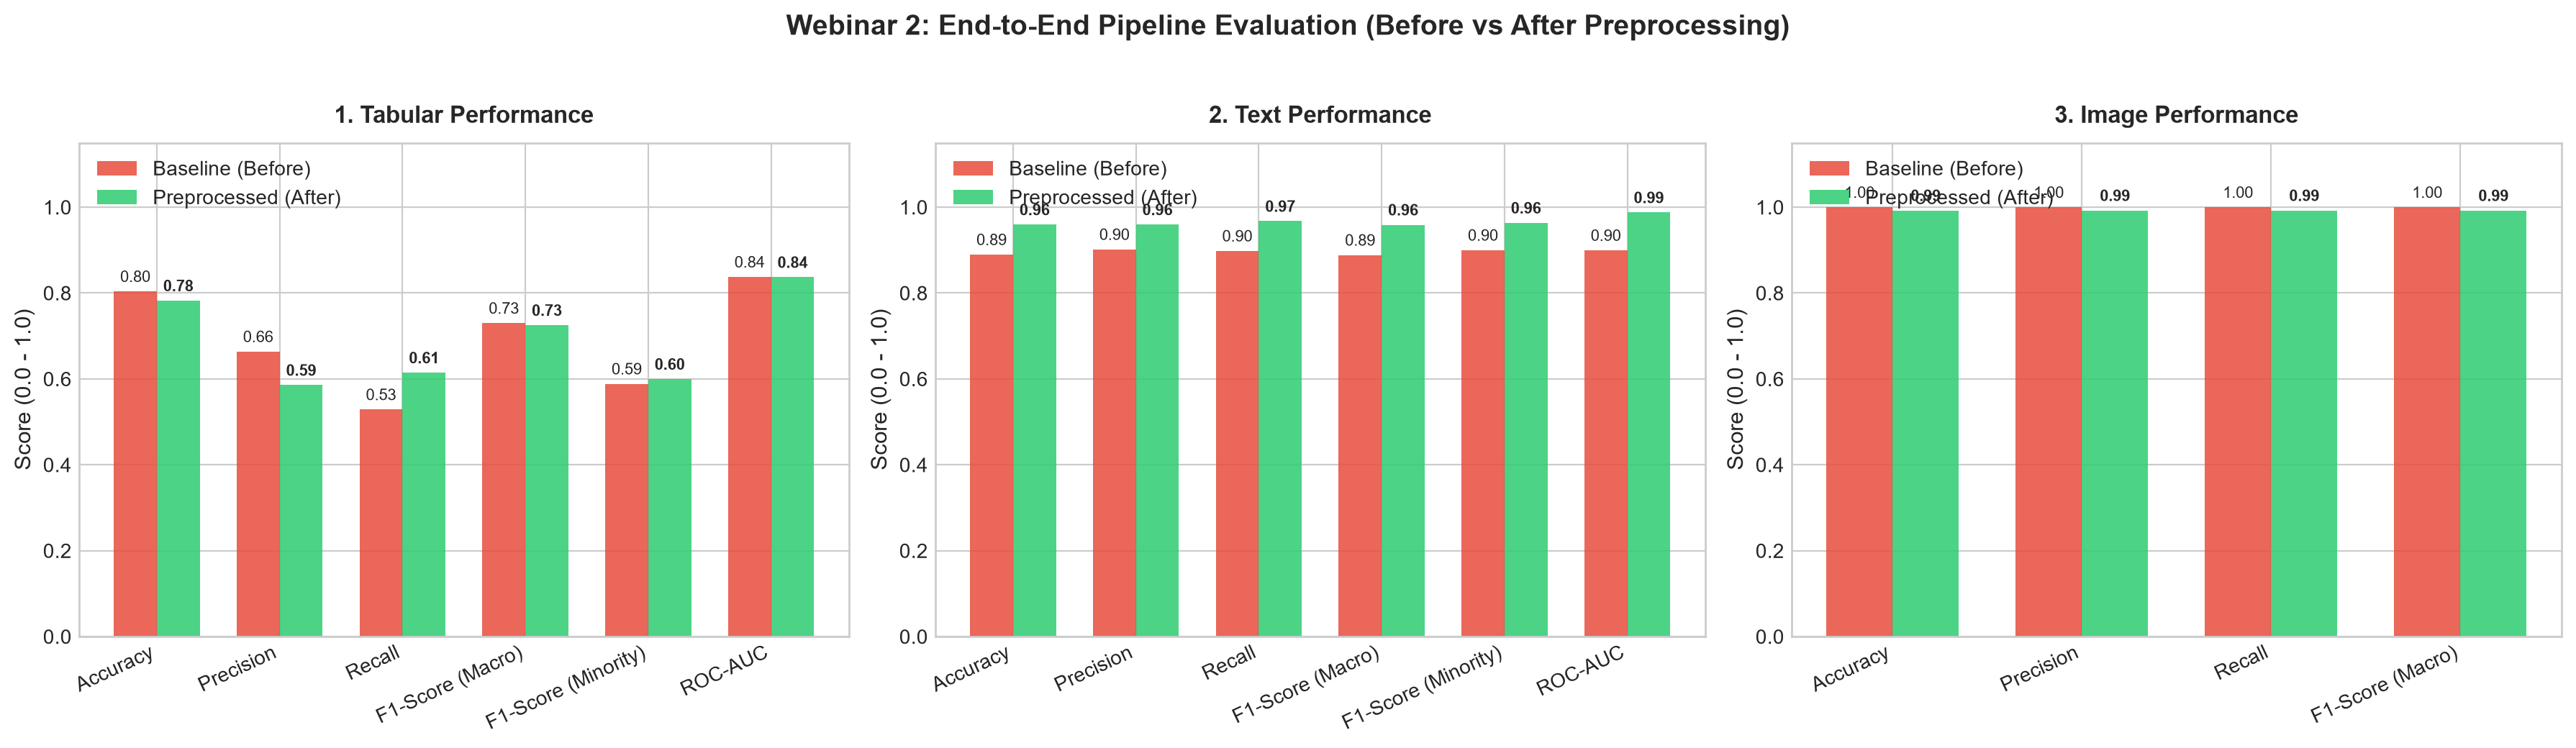

2. Tabular Feature Scaling & Outlier Diagnostics:


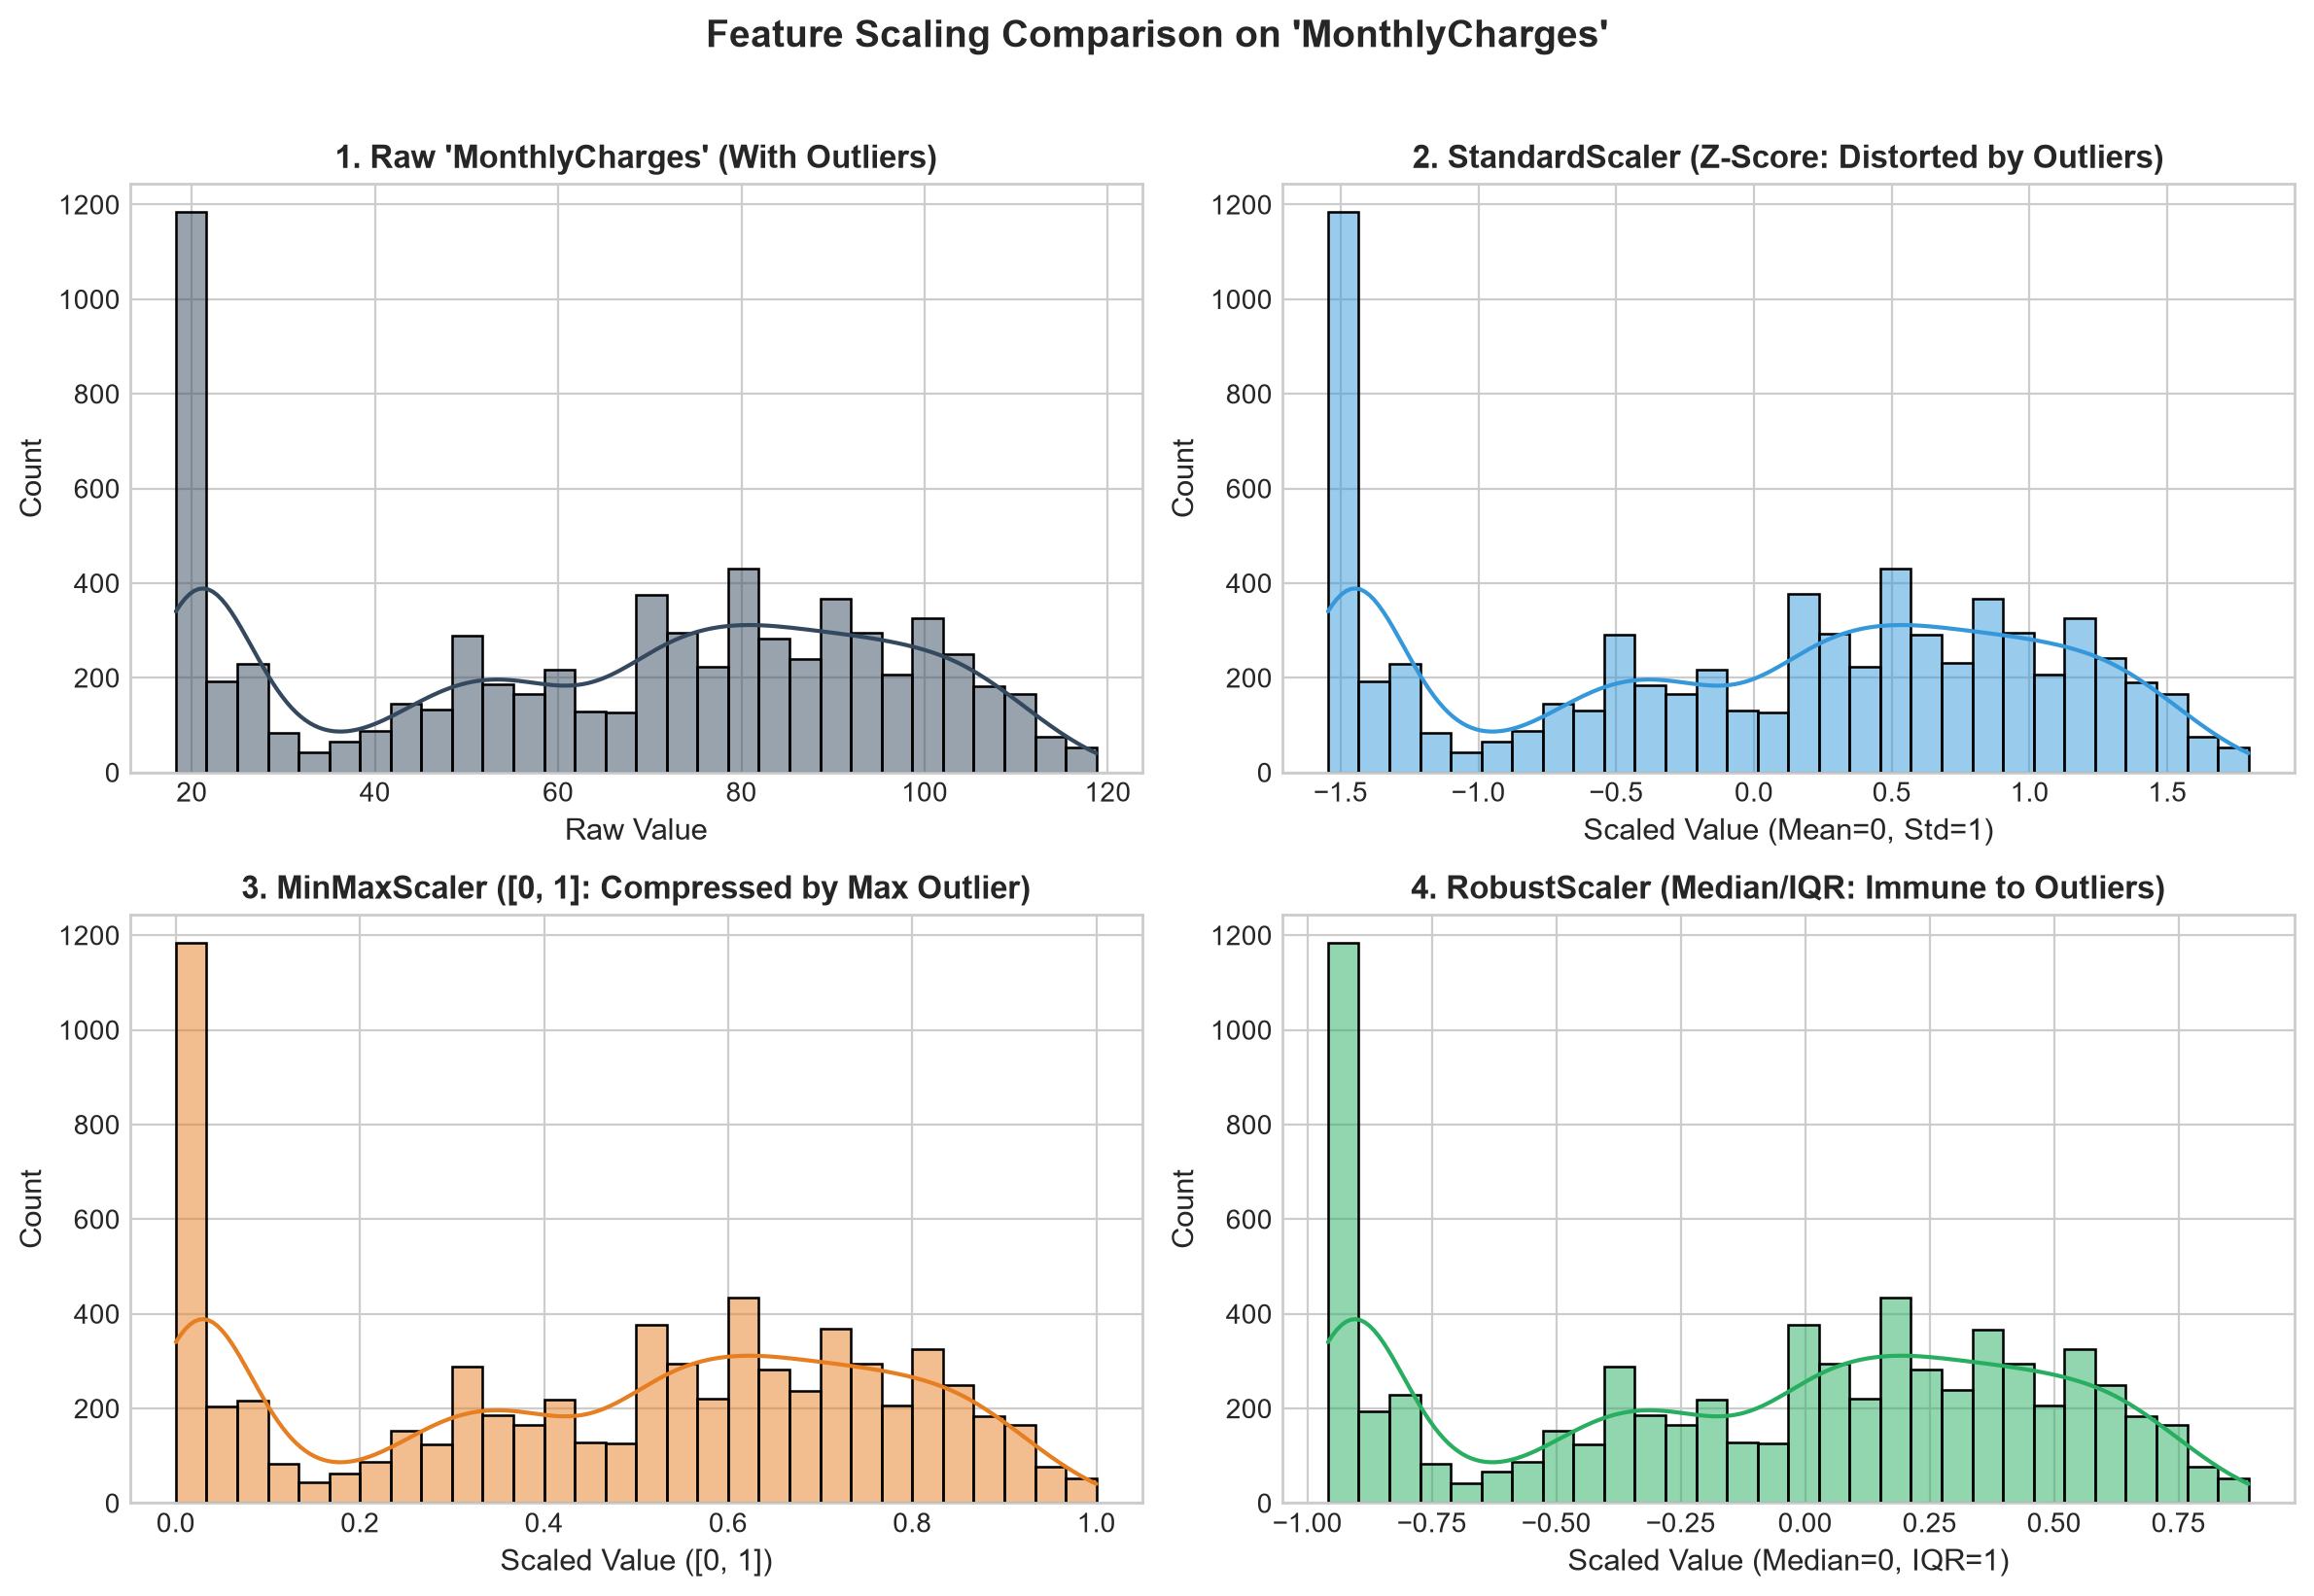

3. Image PCA Scree Plot & Reconstruction:


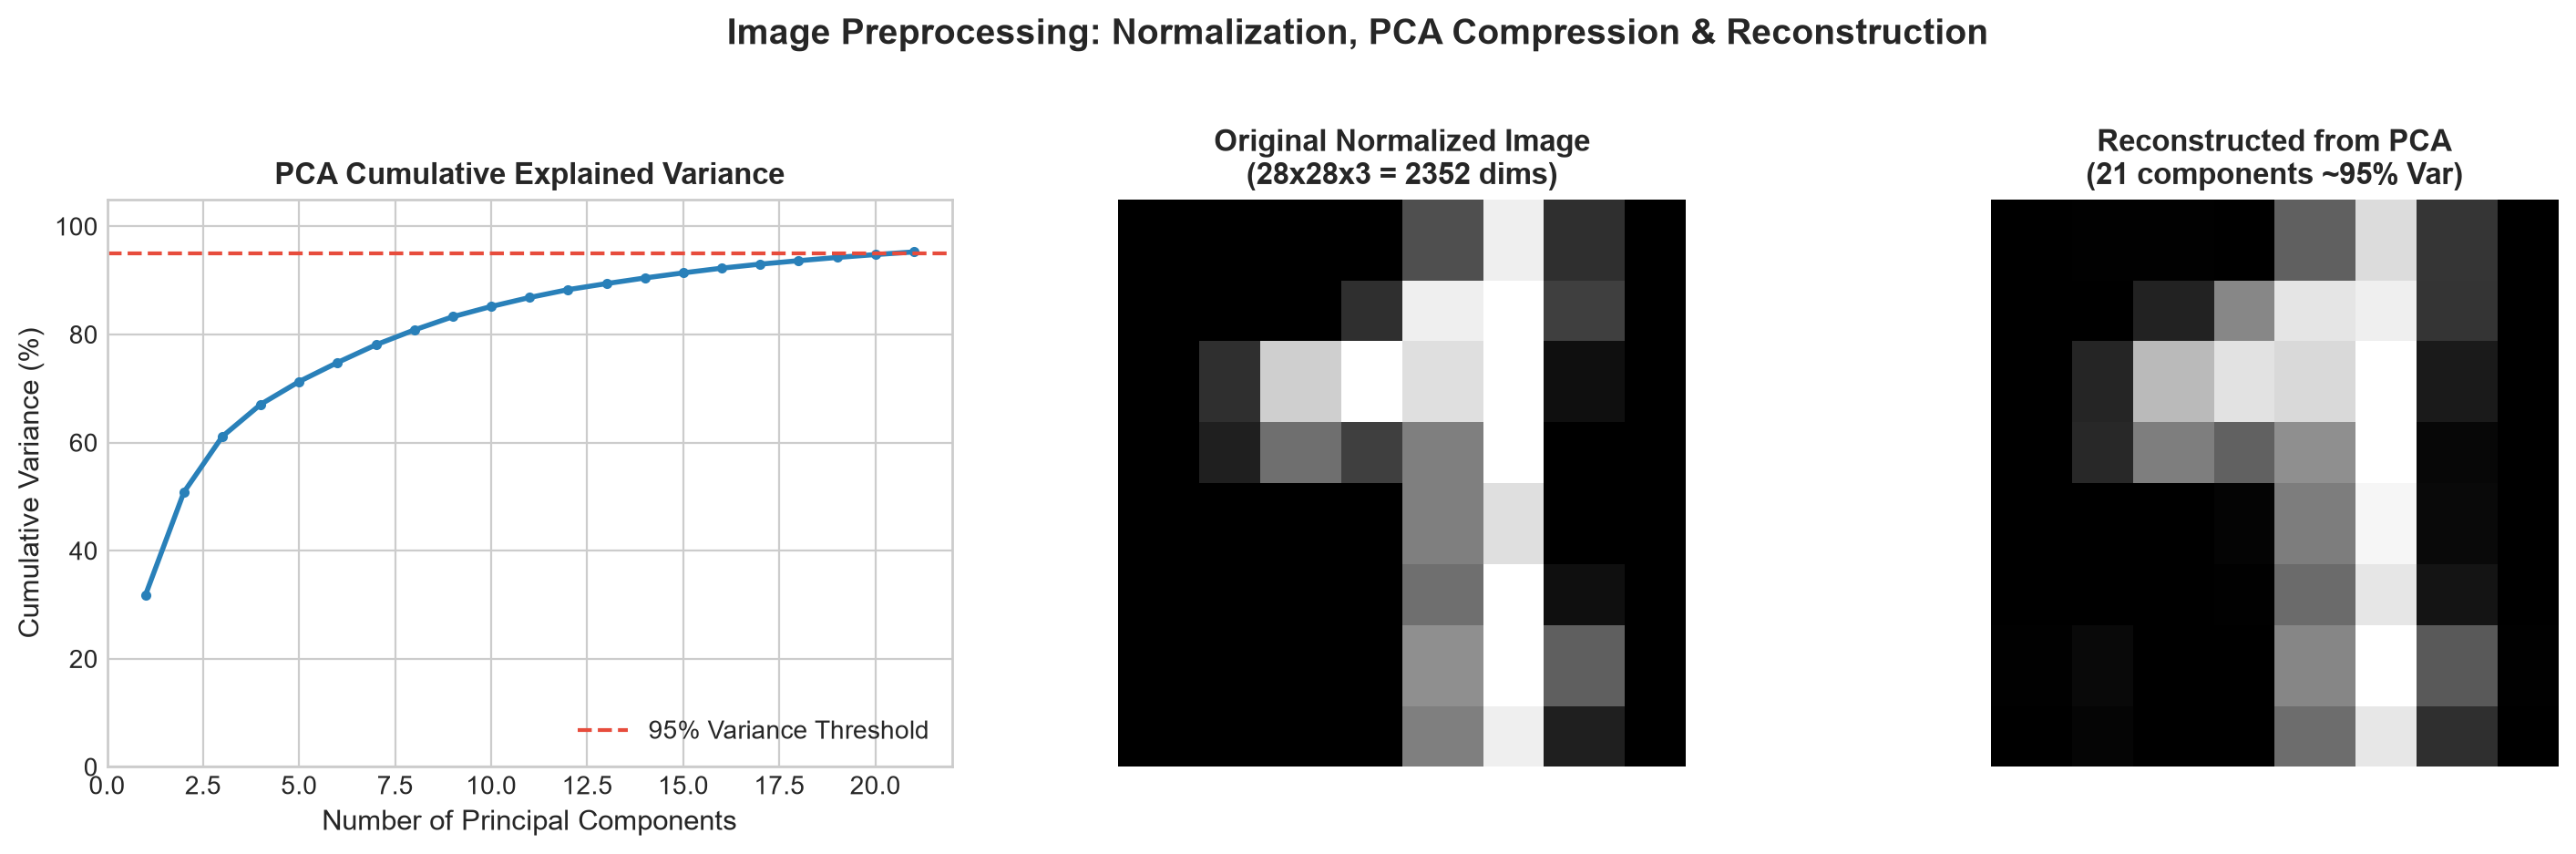

4. Confusion Matrices (Before vs After):


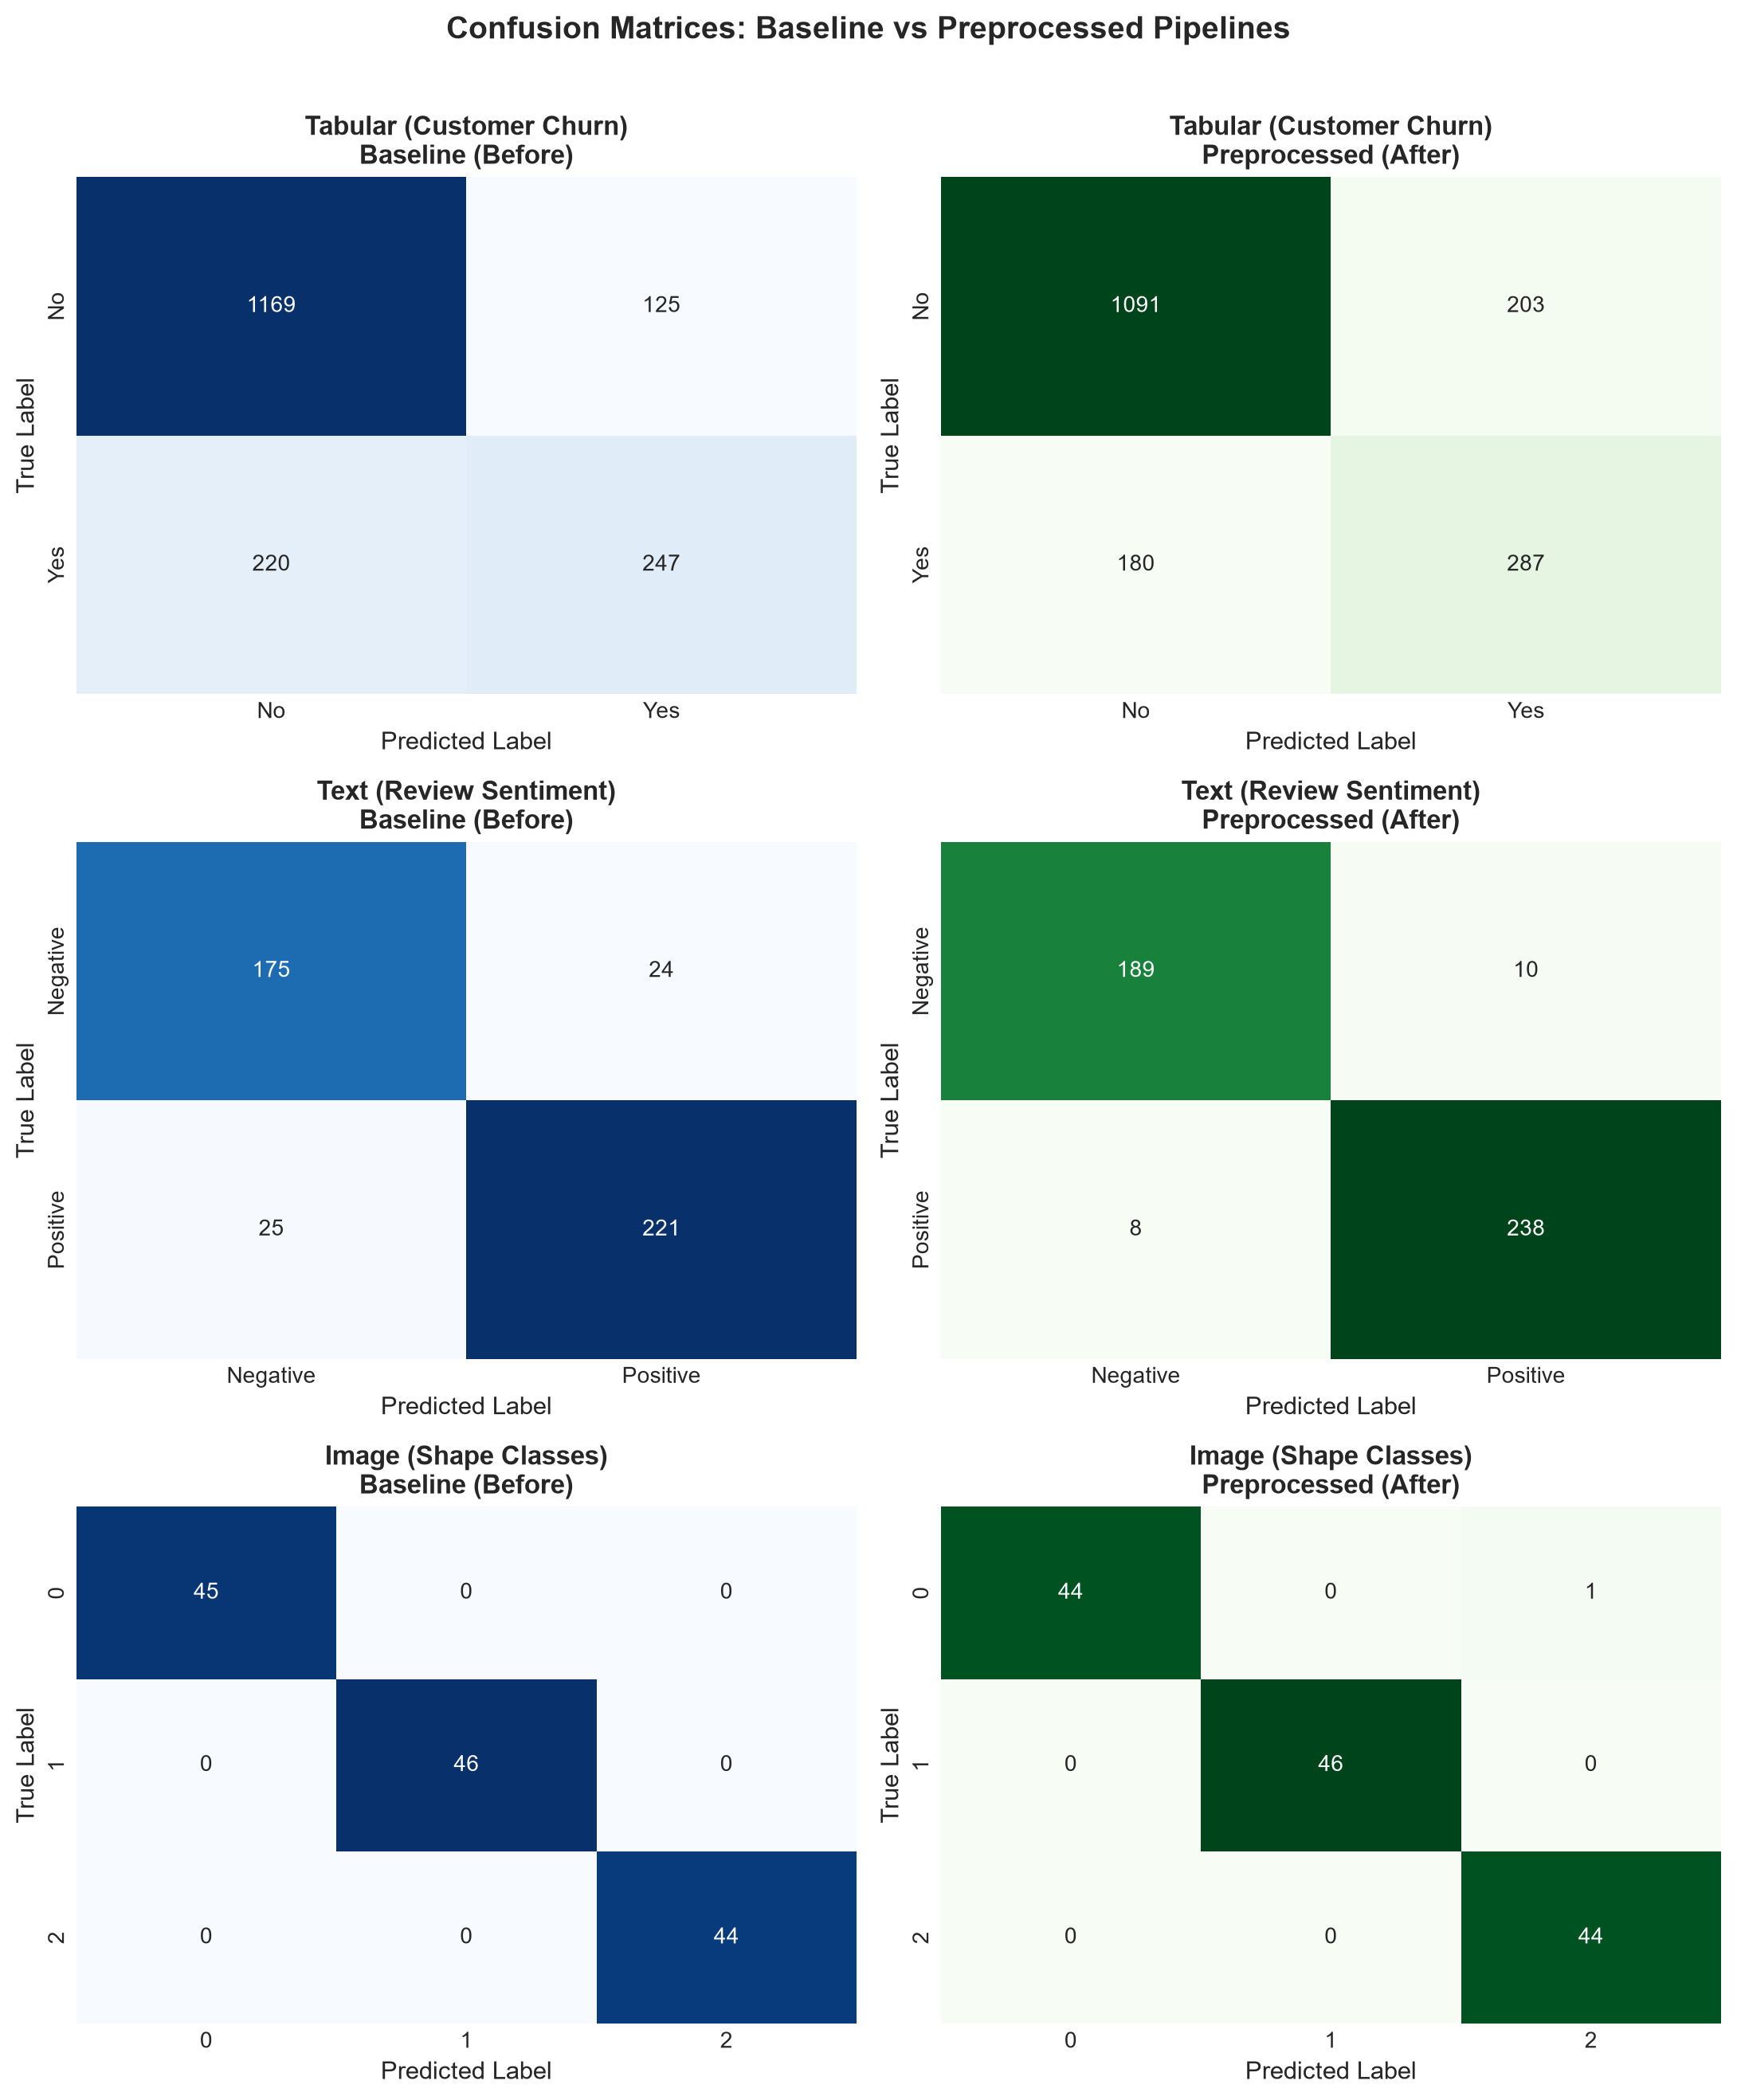

In [4]:
generate_all_report_visuals(tabular_results, text_results, image_results, master_df)

from IPython.display import Image, display
print('1. Benchmark Comparison Across Modalities:')
display(Image(filename='../reports/before_vs_after_benchmarks.png'))

print('2. Tabular Feature Scaling & Outlier Diagnostics:')
display(Image(filename='../reports/tabular_scaling_and_outliers.png'))

print('3. Image PCA Scree Plot & Reconstruction:')
display(Image(filename='../reports/image_pca_and_reconstruction.png'))

print('4. Confusion Matrices (Before vs After):')
display(Image(filename='../reports/confusion_matrices_comparison.png'))